In [1]:
# Install Kaggle API
!pip install -q kaggle

# Upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Move the token to the correct directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset into a dedicated folder
!kaggle datasets download -d dfonseca218/redshift --unzip -p /content/redshift_data

print("Dataset downloaded and extracted!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/dfonseca218/redshift
License(s): unknown
100% 20.3G/20.3G [03:19<00:00, 109MB/s] 

Dataset downloaded and extracted!


In [2]:
import os, glob, h5py, numpy as np, pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

cands = glob.glob("/content/redshift_data/**/*.hdf5", recursive=True) + glob.glob("/content/redshift_data/**/*.h5", recursive=True)
PATH = [f for f in cands if "train" in f.lower()][0]
print("File:", PATH, f"({os.path.getsize(PATH)/1e9:.2f} GB)\n")

h5 = h5py.File(PATH, "r")
keys = list(h5.keys())

IMG_KEY = "image"
img = h5[IMG_KEY]
N = img.shape[0]
non_n = list(img.shape[1:])
BAND_AXIS = int(np.where(np.array(non_n) == 5)[0][0]) + 1   # +1: axis 0 is the galaxy index
print(f"image: shape={img.shape} dtype={img.dtype}  ->  N={N:,}, band axis={BAND_AXIS}")

s = np.sort(rng.choice(N, 32, replace=False))
samp = img[s]
print(f"image values (sample): min={float(samp.min()):.4g} max={float(samp.max()):.4g} mean={float(samp.mean()):.4g}\n")

def one_d_numeric(k):
    d = h5[k]; return d.ndim==1 and d.shape[0]==N and np.issubdtype(d.dtype, np.number)

# redshift target
z_pref = ["specz_redshift","redshift","specz","spec_z","z_spec"]
TARGET = next((k for k in z_pref if k in keys and one_d_numeric(k)), None)
if TARGET is None:
    TARGET = next((k for k in keys if one_d_numeric(k) and "red" in k.lower()), None)

# brightness axis for the split
MAG = "r_cmodel_mag" if "r_cmodel_mag" in keys else \
      next((k for k in keys if one_d_numeric(k) and k.endswith("cmodel_mag")), None)

print("TARGET (redshift):", TARGET)
print("MAG (brightness) :", MAG)
assert TARGET is not None, "No redshift column found — paste `keys` and I'll fix the detector."
assert MAG is not None,   "No magnitude column found — tell me which to use."

zt, mg = h5[TARGET][:], h5[MAG][:]
print(f"\n{TARGET}: min={np.nanmin(zt):.3f} max={np.nanmax(zt):.3f} median={np.nanmedian(zt):.3f}   <- should be ~0–4")
print(f"{MAG}: min={np.nanmin(mg):.3f} max={np.nanmax(mg):.3f} median={np.nanmedian(mg):.3f}   <- should be ~14–25")
print("\nAll keys:\n", keys)

File: /content/redshift_data/5x64x64_training_with_morphology.hdf5 (16.93 GB)

image: shape=(204573, 5, 64, 64) dtype=float32  ->  N=204,573, band axis=1
image values (sample): min=-2.459 max=264.5 mean=0.916

TARGET (redshift): specz_redshift
MAG (brightness) : r_cmodel_mag

specz_redshift: min=0.010 max=3.998 median=0.489   <- should be ~0–4
r_cmodel_mag: min=13.769 max=30.007 median=20.310   <- should be ~14–25

All keys:
 ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness',

In [3]:
num_cols = [k for k in keys if one_d_numeric(k)]
df = pd.DataFrame({k: h5[k][:] for k in num_cols})
n0 = len(df)
mask = np.ones(n0, dtype=bool)

def drop(cond, name):
    global mask
    c = cond & mask
    print(f"  drop {int(c.sum()):>6} : {name}")
    mask &= ~cond

drop(~np.isfinite(df[TARGET].values), "non-finite redshift")
drop(df[TARGET].values <= 0,          "redshift <= 0")
drop(df[TARGET].values > 4.0,         "redshift > 4 (outside design range)")
drop(~np.isfinite(df[MAG].values),    "non-finite r-mag")

for sc in [k for k in num_cols if k.endswith("magsigma")]:   # the broken y-band lives here
    drop(df[sc].values > 1.0, f"{sc} > 1.0 (bad/unmeasured band)")

clean_idx = np.where(mask)[0]
print(f"\nKept {len(clean_idx):,} / {n0:,}  ({len(clean_idx)/n0:.1%})")

chk = np.sort(rng.choice(clean_idx, min(2000, len(clean_idx)), replace=False))
flat = img[chk].reshape(len(chk), -1)
print("sample NaN images:", int(np.isnan(flat).any(1).sum()),
      "| sample all-zero images:", int((flat==0).all(1).sum()))

  drop      0 : non-finite redshift
  drop      0 : redshift <= 0
  drop      0 : redshift > 4 (outside design range)
  drop      0 : non-finite r-mag
  drop     13 : g_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop      1 : i_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop      0 : r_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop     10 : y_cmodel_magsigma > 1.0 (bad/unmeasured band)
  drop      4 : z_cmodel_magsigma > 1.0 (bad/unmeasured band)

Kept 204,545 / 204,573  (100.0%)
sample NaN images: 0 | sample all-zero images: 0


In [4]:
mag_clean = df[MAG].values[clean_idx]
CUT = np.median(mag_clean)                 # knob: median r-mag; >= CUT is "faint"
print(f"brightness cut = {CUT:.3f}\n")

bright_pool = clean_idx[mag_clean <  CUT].copy()
faint_pool  = clean_idx[mag_clean >= CUT].copy()
rng.shuffle(bright_pool); rng.shuffle(faint_pool)

nb = len(bright_pool)
n_tr, n_va, n_ca = int(0.65*nb), int(0.10*nb), int(0.10*nb)
idx_train       = np.sort(bright_pool[:n_tr])
idx_val         = np.sort(bright_pool[n_tr:n_tr+n_va])
idx_calib       = np.sort(bright_pool[n_tr+n_va:n_tr+n_va+n_ca])   # for conformal later
idx_bright_test = np.sort(bright_pool[n_tr+n_va+n_ca:])            # in-distribution test
idx_faint_test  = np.sort(faint_pool)                             # OOD test

for nm, ix in [("train",idx_train),("val",idx_val),("calib",idx_calib),
               ("bright_test (in-dist)",idx_bright_test),("faint_test (OOD)",idx_faint_test)]:
    print(f"  {nm:24} {len(ix):>7,}")

zb, zf = df[TARGET].values[idx_bright_test], df[TARGET].values[idx_faint_test]
print(f"\nmedian z   bright={np.median(zb):.3f}  faint={np.median(zf):.3f}")
print(f"frac z>0.5 bright={(zb>0.5).mean():.1%}  faint={(zf>0.5).mean():.1%}")
try:
    from scipy.stats import ks_2samp
    print("KS distance (bright vs faint z):", round(ks_2samp(zb, zf).statistic, 3), " <- bigger = stronger shift")
except Exception as e:
    print("KS skipped:", e)

np.savez("/content/splits.npz",
         idx_train=idx_train, idx_val=idx_val, idx_calib=idx_calib,
         idx_bright_test=idx_bright_test, idx_faint_test=idx_faint_test,
         TARGET=TARGET, MAG=MAG, CUT=CUT, BAND_AXIS=BAND_AXIS)
print("\nsaved -> /content/splits.npz")

brightness cut = 20.309

  train                     66,476
  val                       10,227
  calib                     10,227
  bright_test (in-dist)     15,342
  faint_test (OOD)         102,273

median z   bright=0.220  faint=0.651
frac z>0.5 bright=13.1%  faint=83.8%
KS distance (bright vs faint z): 0.724  <- bigger = stronger shift

saved -> /content/splits.npz


In [5]:
def to_hwc(a): return np.moveaxis(a, BAND_AXIS, -1)   # -> (batch, H, W, 5)

CHUNK, n_seen = 512, 0
s1 = np.zeros(5, np.float64); s2 = np.zeros(5, np.float64)
for i in range(0, len(idx_train), CHUNK):
    x = np.arcsinh(to_hwc(img[idx_train[i:i+CHUNK]]).astype(np.float32)).reshape(-1, 5)
    s1 += x.sum(0); s2 += (x**2).sum(0); n_seen += x.shape[0]
    if i % (CHUNK*40) == 0: print(f"  {i:>7}/{len(idx_train)}")

BAND_MEAN = (s1/n_seen).astype(np.float32)
BAND_STD  = np.sqrt(np.maximum(s2/n_seen - (s1/n_seen)**2, 1e-12)).astype(np.float32)
print("per-band mean:", np.round(BAND_MEAN,3))
print("per-band std :", np.round(BAND_STD,3))
np.savez("/content/norm.npz", BAND_MEAN=BAND_MEAN, BAND_STD=BAND_STD)
print("saved -> /content/norm.npz")

        0/66476
    20480/66476
    40960/66476
    61440/66476
per-band mean: [0.267 0.457 0.575 0.671 0.755]
per-band std : [0.481 0.677 0.792 0.873 0.943]
saved -> /content/norm.npz


In [6]:
import torch, numpy as np, h5py
from torch.utils.data import Dataset, DataLoader

d = np.load("/content/splits.npz", allow_pickle=True)
TARGET = str(d["TARGET"]); MAG = str(d["MAG"]); BAND_AXIS = int(d["BAND_AXIS"])
idx_train, idx_val, idx_calib = d["idx_train"], d["idx_val"], d["idx_calib"]
idx_bright_test, idx_faint_test = d["idx_bright_test"], d["idx_faint_test"]
nrm = np.load("/content/norm.npz")
BAND_MEAN, BAND_STD = nrm["BAND_MEAN"], nrm["BAND_STD"]

class GalaxyDS(Dataset):
    """Reads 5x64x64 cutouts lazily. asinh -> per-band standardize. Returns (image, z)."""
    def __init__(self, path, indices, target, band_axis, mean, std, augment=False):
        self.path, self.indices = path, np.asarray(indices)
        self.target, self.band_axis = target, band_axis
        self.mean = mean.reshape(5,1,1); self.std = std.reshape(5,1,1)
        self.augment = augment
        self.h5 = None  # opened per-worker

    def __len__(self): return len(self.indices)

    def _ensure_open(self):
        if self.h5 is None:
            self.h5 = h5py.File(self.path, "r")
            self.img = self.h5["image"]; self.z = self.h5[self.target]

    def __getitem__(self, i):
        self._ensure_open()
        j = int(self.indices[i])
        a = self.img[j]                                   # raw cutout
        a = np.moveaxis(a, self.band_axis-1, 0)           # -> (5, H, W)
        a = np.arcsinh(a.astype(np.float32))
        a = (a - self.mean) / self.std
        if self.augment:                                  # galaxies have no "up"
            if np.random.rand() < 0.5: a = a[:, ::-1, :]
            if np.random.rand() < 0.5: a = a[:, :, ::-1]
            a = np.rot90(a, k=np.random.randint(4), axes=(1,2))
        x = torch.from_numpy(np.ascontiguousarray(a))
        y = torch.tensor(float(self.z[j]), dtype=torch.float32)
        return x, y

def make_loader(indices, batch=256, shuffle=False, augment=False, workers=2):
    ds = GalaxyDS(PATH, indices, TARGET, BAND_AXIS, BAND_MEAN, BAND_STD, augment)
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=workers,
                      pin_memory=True, drop_last=shuffle, persistent_workers=(workers>0))

train_loader = make_loader(idx_train, shuffle=True, augment=True)
val_loader   = make_loader(idx_val)
xb, yb = next(iter(train_loader))
print("batch images:", tuple(xb.shape), "| targets:", tuple(yb.shape))
print("image mean≈0? ", float(xb.mean()).__round__(3), " std≈1? ", float(xb.std()).__round__(3))

batch images: (256, 5, 64, 64) | targets: (256,)
image mean≈0?  0.02  std≈1?  1.002


In [7]:
d = np.load("/content/splits.npz", allow_pickle=True)
idx_faint_test_full = d["idx_faint_test"]

# subsample faint_test to ~18k for balanced, fast evaluation
rng = np.random.default_rng(42)
keep = rng.choice(len(idx_faint_test_full), size=min(18000, len(idx_faint_test_full)), replace=False)
idx_faint_test = np.sort(idx_faint_test_full[keep])

# also build brightness bins across BOTH test sets — for the "coverage vs brightness" money plot
mag_all = h5[str(d["MAG"])][:]
test_all = np.concatenate([d["idx_bright_test"], idx_faint_test])
mags_test = mag_all[test_all]
bin_edges = np.quantile(mags_test, np.linspace(0, 1, 7))   # 6 brightness bins
print("brightness bin edges (r-mag):", np.round(bin_edges, 2))

np.savez("/content/splits.npz",
         idx_train=d["idx_train"], idx_val=d["idx_val"], idx_calib=d["idx_calib"],
         idx_bright_test=d["idx_bright_test"],
         idx_faint_test=idx_faint_test,
         idx_faint_test_full=idx_faint_test_full,   # kept in case you want the full pile later
         test_bin_edges=bin_edges,
         TARGET=str(d["TARGET"]), MAG=str(d["MAG"]), CUT=float(d["CUT"]), BAND_AXIS=int(d["BAND_AXIS"]))
print(f"faint_test trimmed: {len(idx_faint_test_full):,} -> {len(idx_faint_test):,}")
print(f"bright_test: {len(d['idx_bright_test']):,}  |  now balanced for evaluation")

brightness bin edges (r-mag): [14.35 18.43 19.37 20.48 21.18 22.32 26.72]
faint_test trimmed: 102,273 -> 18,000
bright_test: 15,342  |  now balanced for evaluation


Mini size run

In [8]:
# Subsample indices for a fast dry run
rng = np.random.default_rng(42)

# Select 2,000 for training and 500 for validation (adjust sizes as needed)
mini_idx_train = rng.choice(idx_train, size=min(2000, len(idx_train)), replace=False)
mini_idx_val = rng.choice(idx_val, size=min(500, len(idx_val)), replace=False)

# Create new lightweight loaders
mini_train_loader = make_loader(mini_idx_train, batch=128, shuffle=True, augment=True)
mini_val_loader = make_loader(mini_idx_val, batch=128, shuffle=False)

print(f"Mini train size: {len(mini_idx_train):,} | Mini val size: {len(mini_idx_val):,}")

Mini train size: 2,000 | Mini val size: 500


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal, Categorical, MixtureSameFamily
from tqdm.auto import tqdm

class GalaxyMDN(nn.Module):
    def __init__(self, in_channels=5, num_components=3):
        super().__init__()
        self.num_components = num_components

        # 1. Feature Extractor (Simple CNN backbone)
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # 2. MDN Heads
        self.pi_head = nn.Linear(512, num_components)
        self.mu_head = nn.Linear(512, num_components)
        self.sigma_head = nn.Linear(512, num_components)

    def forward(self, x):
        h = self.features(x)

        # Mixing coefficients must sum to 1 (softmax)
        pi = F.softmax(self.pi_head(h), dim=-1)

        # Means can be any real number (redshift target range is ~0 to 4)
        mu = self.mu_head(h)

        # Standard deviations must be strictly positive (softplus + epsilon)
        sigma = F.softplus(self.sigma_head(h)) + 1e-6

        return pi, mu, sigma

In [10]:
def mdn_loss(pi, mu, sigma, target):
    # pi shape: (B, K), mu shape: (B, K), sigma shape: (B, K), target shape: (B,)

    # Define the mixture distribution
    mix = Categorical(probs=pi)
    comp = Normal(loc=mu, scale=sigma)
    gmm = MixtureSameFamily(mix, comp)

    # Calculate negative log-likelihood
    loss = -gmm.log_prob(target)
    return loss.mean()

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GalaxyMDN(in_channels=5, num_components=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10 # Keep low for testing

best_val_loss = float('inf')
CHECKPOINT_PATH = "/content/best_mdn_model.pth"

print(f"Training on {device}...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    # --- TRAINING PASS ---
    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pi, mu, sigma = model(x_batch)
        loss = mdn_loss(pi, mu, sigma, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # --- VALIDATION PASS ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            pi, mu, sigma = model(x_val)
            loss = mdn_loss(pi, mu, sigma, y_val)
            val_loss += loss.item() * x_val.size(0)

    val_loss /= len(val_loader.dataset)
    print(f"Epoch {epoch+1} | Train NLL: {train_loss:.4f} | Val NLL: {val_loss:.4f}")

    # --- CHECKPOINTING ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        # Save the model state, optimizer state, and epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, CHECKPOINT_PATH)
        print(f"  🌟 Checkpoint saved! New best Val NLL: {best_val_loss:.4f}")

Training on cuda...


Epoch 1/10:   0%|          | 0/259 [00:00<?, ?it/s]

Epoch 1 | Train NLL: -0.8768 | Val NLL: -1.4081
  🌟 Checkpoint saved! New best Val NLL: -1.4081


Epoch 2/10:   0%|          | 0/259 [00:00<?, ?it/s]

Epoch 2 | Train NLL: -1.3993 | Val NLL: -1.5969
  🌟 Checkpoint saved! New best Val NLL: -1.5969


...

Epoch 8 | Train NLL: -1.6976 | Val NLL: -1.8378


Epoch 9/10:   0%|          | 0/259 [00:00<?, ?it/s]

Epoch 9 | Train NLL: -1.7376 | Val NLL: -1.9280
  🌟 Checkpoint saved! New best Val NLL: -1.9280


Epoch 10/10:   0%|          | 0/259 [00:00<?, ?it/s]

Epoch 10 | Train NLL: -1.7658 | Val NLL: -1.8969


In [12]:
# Re-instantiate the model structure (if starting a fresh session) or just load into existing
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved state dictionary
checkpoint = torch.load("/content/best_mdn_model.pth", map_location=device, weights_only=True)

# Apply the best weights to your model
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Successfully loaded best model from Epoch {checkpoint['epoch']+1} with Val NLL: {checkpoint['val_loss']:.4f}")

Successfully loaded best model from Epoch 9 with Val NLL: -1.9280


In [13]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()
true_z = []
expected_z = []
max_prob_z = []
uncertainties = []

with torch.no_grad():
    for x_val, y_val in val_loader:
        x_val = x_val.to(device)
        pi, mu, sigma = model(x_val)

        # Move tensors back to CPU for numpy operations
        pi = pi.cpu().numpy()
        mu = mu.cpu().numpy()
        sigma = sigma.cpu().numpy()

        # 1. Expected Value (Weighted sum of means)
        z_expected = np.sum(pi * mu, axis=1)

        # 2. Most likely component's mean (Alternative approach)
        best_comp = np.argmax(pi, axis=1)
        z_max_prob = mu[np.arange(mu.shape[0]), best_comp]

        # 3. Overall variance (Law of Total Variance)
        # Var(Y) = E[Var(Y|X)] + Var(E[Y|X])
        variance = np.sum(pi * (sigma**2 + mu**2), axis=1) - z_expected**2
        std_dev = np.sqrt(variance)

        true_z.extend(y_val.numpy())
        expected_z.extend(z_expected)
        max_prob_z.extend(z_max_prob)
        uncertainties.extend(std_dev)

true_z = np.array(true_z)
expected_z = np.array(expected_z)

print("\n--- Validation Metrics ---")
print(f"MAE (Expected Value): {mean_absolute_error(true_z, expected_z):.4f}")
print(f"RMSE (Expected Value): {np.sqrt(mean_squared_error(true_z, expected_z)):.4f}")
print(f"Mean Predictive Uncertainty (Std Dev): {np.mean(uncertainties):.4f}")


--- Validation Metrics ---
MAE (Expected Value): 0.0650
RMSE (Expected Value): 0.2072
Mean Predictive Uncertainty (Std Dev): 0.1009


Running evaluation on the combined test set...

Metrics by Brightness Bin (r-mag):


,Bin Center,Bin Range,Count,MAE,Mean Uncertainty (σ),Coverage (2σ)
0,16.387294,14.3-18.4,5557,0.019592,0.036936,0.990822
1,18.895661,18.4-19.4,5557,0.055722,0.093138,0.987403
2,19.922140,19.4-20.5,5557,0.135268,0.197641,0.985424
3,20.829130,20.5-21.2,5557,0.162019,0.231936,0.982724
4,21.750883,21.2-22.3,5557,0.365848,0.325402,0.874033
5,24.519743,22.3-26.7,5557,0.592400,0.218031,0.389599


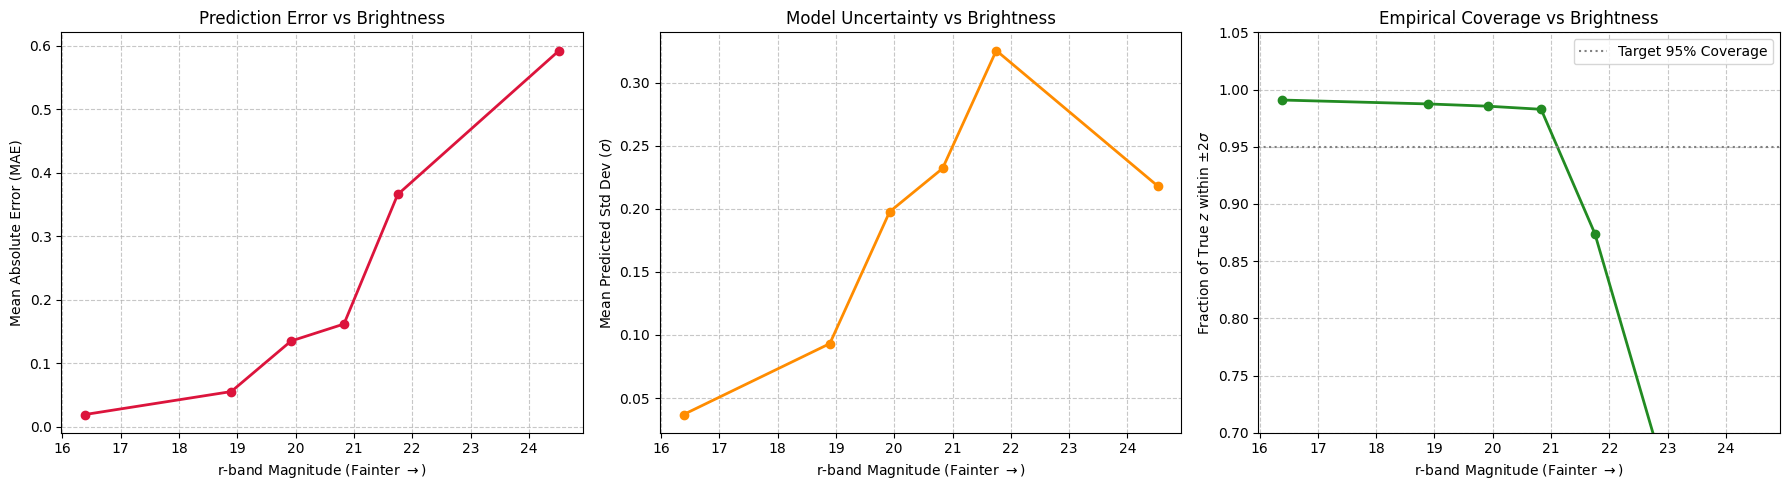

In [16]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 1. Load splits and define the combined test set
d = np.load("/content/splits.npz", allow_pickle=True)
idx_bright = d["idx_bright_test"]
idx_faint = d["idx_faint_test"]
bin_edges = d["test_bin_edges"]
MAG_KEY = str(d["MAG"])

# Combine test sets
test_indices = np.concatenate([idx_bright, idx_faint])
test_loader = make_loader(test_indices, batch=256, shuffle=False)

# Get the corresponding brightness magnitudes from the HDF5 file
# Note: Ensure your h5 file is still open, or re-open it: h5 = h5py.File(PATH, "r")
# Load the 1D array into RAM first, then index with numpy
all_mags = h5[MAG_KEY][:]
test_mags = all_mags[test_indices]

# 2. Run Inference
model.eval()
true_z, expected_z, uncertainties = [], [], []

print("Running evaluation on the combined test set...")
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        pi, mu, sigma = model(x_batch)

        pi = pi.cpu().numpy()
        mu = mu.cpu().numpy()
        sigma = sigma.cpu().numpy()

        # Expected value and variance
        z_exp = np.sum(pi * mu, axis=1)
        variance = np.sum(pi * (sigma**2 + mu**2), axis=1) - z_exp**2
        std_dev = np.sqrt(variance)

        true_z.extend(y_batch.numpy())
        expected_z.extend(z_exp)
        uncertainties.extend(std_dev)

true_z = np.array(true_z)
expected_z = np.array(expected_z)
uncertainties = np.array(uncertainties)

# 3. Bin the results by brightness
# np.digitize returns 1 for the first bin, so we subtract 1 for 0-indexing
bin_idx = np.digitize(test_mags, bin_edges) - 1
# Clip to ensure edge cases (exactly at max edge) stay in the last bin
bin_idx = np.clip(bin_idx, 0, len(bin_edges) - 2)

# Calculate metrics per bin
results = []
for i in range(len(bin_edges) - 1):
    mask = (bin_idx == i)
    if not mask.any(): continue

    z_t = true_z[mask]
    z_e = expected_z[mask]
    u_pred = uncertainties[mask]

    # 95% Confidence Interval Coverage (approx +/- 2 standard deviations)
    # Checks if true z is within [Expected Z - 2*StdDev, Expected Z + 2*StdDev]
    lower_bound = z_e - (2 * u_pred)
    upper_bound = z_e + (2 * u_pred)
    coverage = np.mean((z_t >= lower_bound) & (z_t <= upper_bound))

    results.append({
        "Bin Center": (bin_edges[i] + bin_edges[i+1]) / 2,
        "Bin Range": f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}",
        "Count": mask.sum(),
        "MAE": mean_absolute_error(z_t, z_e),
        "Mean Uncertainty (σ)": np.mean(u_pred),
        "Coverage (2σ)": coverage
    })

df_res = pd.DataFrame(results)
print("\nMetrics by Brightness Bin (r-mag):")
display(df_res)

# 4. Plot the "Money Plots"
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
x_vals = df_res["Bin Center"]

# Plot 1: Error vs Brightness
axs[0].plot(x_vals, df_res["MAE"], marker='o', color='crimson', lw=2)
axs[0].set_title("Prediction Error vs Brightness")
axs[0].set_xlabel("r-band Magnitude (Fainter $\\rightarrow$)")
axs[0].set_ylabel("Mean Absolute Error (MAE)")
axs[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Model Confidence vs Brightness
axs[1].plot(x_vals, df_res["Mean Uncertainty (σ)"], marker='o', color='darkorange', lw=2)
axs[1].set_title("Model Uncertainty vs Brightness")
axs[1].set_xlabel("r-band Magnitude (Fainter $\\rightarrow$)")
axs[1].set_ylabel("Mean Predicted Std Dev ($\\sigma$)")
axs[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: Coverage vs Brightness
axs[2].plot(x_vals, df_res["Coverage (2σ)"], marker='o', color='forestgreen', lw=2)
axs[2].axhline(0.95, color='gray', linestyle=':', label='Target 95% Coverage')
axs[2].set_title("Empirical Coverage vs Brightness")
axs[2].set_xlabel("r-band Magnitude (Fainter $\\rightarrow$)")
axs[2].set_ylabel("Fraction of True $z$ within $\\pm 2\\sigma$")
axs[2].set_ylim(0.7, 1.05)
axs[2].legend()
axs[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()